# Case: ASD field uncertainty budget — real pipeline code

**Reference:** Werfeli, M., Antala, M., Abdelmajeed, A.Y.A. et al. *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."* Precision Agric 27, 153 (2026).
https://doi.org/10.1007/s11119-026-10455-1

This notebook implements the field-uncertainty-budget pipeline used for
the ASD/SVC part of the campaign (originally written by Mike Werfeli): time
synchronising the white-panel reference (`time_to_seconds`,
`irradiance_interpol`), estimating cloud-driven uncertainty
(`u_cloud_estimation`), reading the raw field export
(`read_Field_day_csv`), interpolating the panel certificate
(`rho_panel_interp`), computing reflectance (`refl_calculator`), and
combining random and systematic uncertainty with `punpy.MCPropagation`.

It runs **end to end on one real example dataset**: Plot 103 of the 2025
Norway campaign, using the real raw ASD instrument output (trimmed to just
Plots 103 and 105 — 105 is needed because the white-reference panel is
interpolated in time between two consecutive plot visits) and the real panel
calibration certificates for both white reference panels (WP1/AM and
WP2/LM).

!!! note "What stays out of scope"
    The instrument's own internal radiometric calibration (factory
    calibration of the ASD/SVC spectroradiometer itself) is not part of this
    code and is not discussed here — this notebook starts from the
    instrument's raw digital-number (DN) output, exactly like the original
    script does.

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator
import punpy
import comet_maths as ctm

DATA_DIR = "../data/case-asd-svc-plot103"
RAW_PATH = f"{DATA_DIR}/raw_ASD_plot103_105.csv"
PANEL_AM_PATH = f"{DATA_DIR}/panel_certificate_WP1_AM.csv"      # WP1 / "AM" / Alex's panel
PANEL_LM_PATH = f"{DATA_DIR}/panel_certificate_WP2_LM.csv"      # WP2 / "LM" / Laura's panel
U_PANEL_AM_PATH = f"{DATA_DIR}/panel_uncertainty_WP1_AM.csv"
U_PANEL_LM_PATH = f"{DATA_DIR}/panel_uncertainty_WP2_LM.csv"

# Number of Monte Carlo realisations used by punpy for every propagation
# step below (same order of magnitude as the original campaign code).
realisations_n = int(1e4)

## 1. Reading the raw field file

The raw ASD export has one row per scan, with instrument metadata in the
first columns and the measured spectrum (one column per wavelength, 350 to
2500 nm) after that. Three kinds of rows are mixed together in the same
file, distinguished only by the `File Name` column:

- `plot_103_fsfwr_*` — white-reference-panel scans against **WP1** ("AM" /
  Alex's panel)
- `plot_103_laurawr_*` — white-reference-panel scans against **WP2** ("LM" /
  Laura's panel)
- `plot_103_1st_*` / `_2nd_*` / ... — the actual target (vegetation) scans,
  5 positions x 5 repeat scans = 25 target spectra for the plot

`read_Field_day_csv` below splits the file into these three groups, for
each plot in `plot_no`.

In [2]:
# Convert a datetime.time (or array of them) to seconds since midnight.
def time_to_seconds(t):
    if type(t) == np.ndarray:
        return [i.hour * 3600 + i.minute * 60 + i.second for i in t]
    elif type(t) != list:
        return t.hour * 3600 + t.minute * 60 + t.second


def read_Field_day_csv(path, plot_no):
    df = pd.read_csv(path, low_memory=False)
    wvl_idx, plot_idx = 22, 10  # fixed column layout of the ASD field-day export

    L_data = df.iloc[:, wvl_idx:]
    wvls = L_data.columns.astype(float).tolist()

    plot_data_dict, WR_LM_dict, WR_AM_dict = {}, {}, {}
    plot_names = np.asarray(df.iloc[:, plot_idx].tolist())
    t_stamps = pd.to_datetime(df['Acquisition Time']).dt.time.to_numpy()

    for pid in plot_no:
        positions_fsf = np.asarray([i for i, s in enumerate(plot_names) if "fsfwr" in s and pid in s])
        positions_laura = np.asarray([i for i, s in enumerate(plot_names) if "laurawr" in s and pid in s])

        WR_AM_dict[pid] = (np.asarray(L_data.iloc[positions_fsf, :]), np.asarray(t_stamps[positions_fsf]))
        WR_LM_dict[pid] = (np.asarray(L_data.iloc[positions_laura, :]), np.asarray(t_stamps[positions_laura]))

        position_plot = np.asarray([i for i, s in enumerate(plot_names) if pid in s])
        mask = ~np.isin(position_plot, np.concatenate([positions_fsf, positions_laura]))
        position_plot = position_plot[mask]
        plot_data_dict[pid] = (np.asarray(L_data.iloc[position_plot, :]), np.asarray(t_stamps[position_plot]))

    return plot_data_dict, WR_LM_dict, WR_AM_dict, wvls


plot_no = ['103', '105']
L, WR_LM, WR_AM, wvls = read_Field_day_csv(RAW_PATH, plot_no)

print(f"{len(L['103'][0])} target scans for plot 103")
print(f"{len(WR_AM['103'][0])} WP1/AM panel scans, {len(WR_LM['103'][0])} WP2/LM panel scans for plot 103")

25 target scans for plot 103
5 WP1/AM panel scans, 5 WP2/LM panel scans for plot 103


## 2. Panel calibration certificates

Each white reference panel has its own certificate: a wavelength-dependent
reflectance factor $\rho_R$ (how much of the incoming light the panel
reflects) and its calibration uncertainty. WP1 and WP2 use different
certificate file formats (a quirk of how each was originally issued), so
`rho_panel_interp` below handles both, interpolating each onto the
instrument's own wavelength grid.

In [3]:
def rho_panel_interp(file_path, wvls, wvls_range=(350, 2500)):
    wvls = np.asarray(wvls)
    if 'WP1_AM' in file_path:
        df = pd.read_csv(file_path)
        wvls_rho = np.asanyarray(df['lambda'])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        col = 'sigma (k=2)' if 'uncertainty' in file_path else 'rho'
        rho_interp = np.asarray(df[col][idx])
        wvls_rho = wvls_rho[idx]
        cs = PchipInterpolator(wvls_rho, rho_interp) if 'uncertainty' in file_path else CubicSpline(wvls_rho, rho_interp)
        wvls_new = np.arange(wvls_range[0], wvls_range[1] + 1)
        return cs(wvls_new)
    elif 'WP2_LM' in file_path:
        df = pd.read_csv(file_path)
        if 'uncertainty' in file_path:
            wvls_rho = np.asarray(df.iloc[:, 0])
            idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
            u_raw = np.asarray(df.iloc[idx, 1])
            cs = PchipInterpolator(wvls_rho[idx], u_raw)
            return cs(np.arange(wvls_range[0], wvls_range[1] + 1))
        wvls_rho = np.asarray(df.iloc[:, 0])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        rho_raw = np.asarray(df.iloc[idx, 1])
        rho_raw_dec = np.asarray(df.iloc[idx, 2])
        # the certificate stores reflectance as separate integer/decimal columns; recombine into one float
        num_digits = np.floor(np.log10(rho_raw_dec) + 1).astype(int)
        rho_raw = (rho_raw + rho_raw_dec / (10 ** num_digits)) / 100
        rho = np.ones(len(wvls))
        wvls_rho2 = wvls_rho[idx]
        cs = CubicSpline(wvls_rho2, rho_raw)
        wvls_ip = np.arange(wvls_range[0], wvls_rho[max(idx)])
        rho_interp = cs(wvls_ip)
        rho[:len(rho_raw) - 1] *= rho_interp
        ones_idx = np.where(rho == 1)
        if len(ones_idx[0]) > 0:
            rho[ones_idx] *= rho_interp[ones_idx[0][0] - 1]
        return rho


rho_interp_AM = rho_panel_interp(PANEL_AM_PATH, wvls)
rho_interp_LM = rho_panel_interp(PANEL_LM_PATH, wvls)
u_rho_am_abs = rho_interp_AM * (rho_panel_interp(U_PANEL_AM_PATH, wvls) / 2)
u_rho_lm_abs = rho_interp_LM * (rho_panel_interp(U_PANEL_LM_PATH, wvls) / 2)

print(f"WP1/AM panel reflectance factor at 550nm: {rho_interp_AM[list(np.arange(350,2501)).index(550)]:.4f}")

WP1/AM panel reflectance factor at 550nm: 0.9922


## 3. Reflectance formula and time interpolation

ASD and SVC do not measure the target and the reference panel at the same
instant, so the panel reading has to be interpolated in time to the target's
own acquisition time. Both this interpolation and the reflectance formula
itself are propagated through `punpy`'s Monte Carlo engine later on — here
we just define the two functions:

$$R = \frac{DN_T}{DN_R} \cdot \rho_R \cdot c_\text{clouds}$$

In [4]:
# Interpolate the white-reference-panel signal to the target's acquisition
# time. Built to accept punpy's Monte Carlo sample arrays (extra dimension
# n_MC), not just single spectra.
def irradiance_interpol(E_start, E_end, E_start_t, E_end_t, L_t):
    if E_start.ndim == 1:
        E_start, E_end = E_start[:, None], E_end[:, None]
        E_start_t, E_end_t, L_t = np.atleast_1d(E_start_t), np.atleast_1d(E_end_t), np.atleast_1d(L_t)
    n_bands, n_MC = E_start.shape
    E_interp = np.empty((n_bands, n_MC))
    for k in range(n_MC):
        t = np.array([E_start_t[k], E_end_t[k]])
        for i in range(n_bands):
            E_interp[i, k] = np.interp(L_t[k], t, np.array([E_start[i, k], E_end[i, k]]))
    return E_interp


def refl_calculator(DN_target, DN_panel_interp, rho_panel, c_cloud):
    return DN_target / DN_panel_interp * rho_panel * c_cloud


# White-reference panel readings for plot 103, and the next plot (105) they
# are interpolated towards.
E_start_AM = np.mean(WR_AM['103'][0], axis=0)
E_end_AM = np.mean(WR_AM['105'][0], axis=0)
E_start_t_AM = np.mean(time_to_seconds(WR_AM['103'][1]))
E_end_t_AM = np.mean(time_to_seconds(WR_AM['105'][1]))

E_start_LM = np.mean(WR_LM['103'][0], axis=0)
E_end_LM = np.mean(WR_LM['105'][0], axis=0)
E_start_t_LM = np.mean(time_to_seconds(WR_LM['103'][1]))
E_end_t_LM = np.mean(time_to_seconds(WR_LM['105'][1]))

## 4. Reflectance for every target scan (both panels)

Computed for all 25 target scans of Plot 103, against **both** WP1/AM and
WP2/LM (the same target measurements, referenced two different ways) — this
is what later lets the cross-sensor intercomparison notebook show how much
the choice of reference panel alone changes the result.

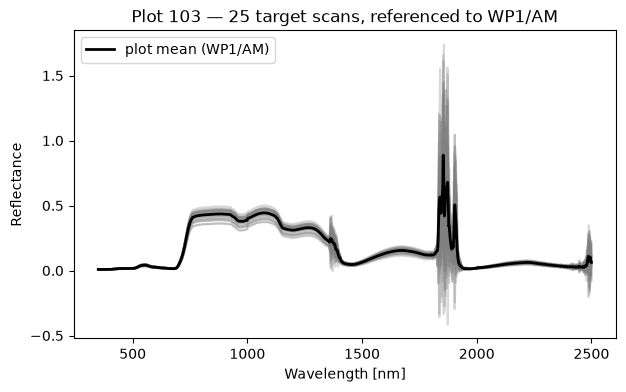

In [5]:
R_dict, E_interp_dict = {}, {}

for panel_name, (E_start, E_end, E_start_t, E_end_t, rho) in {
    'AM': (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM, rho_interp_AM),
    'LM': (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM, rho_interp_LM),
}.items():
    R_list, E_interp_list = [], []
    for i in range(len(L['103'][0])):
        DN = L['103'][0][i]
        DN_t = time_to_seconds(L['103'][1][i])
        c_cloud = np.ones(len(DN))
        E_interp = np.squeeze(irradiance_interpol(E_start, E_end, E_start_t, E_end_t, DN_t))
        R = refl_calculator(DN, E_interp, rho, c_cloud)
        R_list.append(R)
        E_interp_list.append(E_interp)
    R_dict['103_' + panel_name] = R_list
    E_interp_dict['103_' + panel_name] = E_interp_list[-1]  # last E_interp reused below for the uncertainty budget

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for r in R_dict['103_AM']:
    plt.plot(wvls, r, color='grey', alpha=0.3)
plt.plot(wvls, np.mean(R_dict['103_AM'], axis=0), color='k', linewidth=2, label='plot mean (WP1/AM)')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend(); plt.title('Plot 103 — 25 target scans, referenced to WP1/AM')
plt.show()

## 5. Random uncertainty: sensor noise

The random (independent) component of the panel measurement's uncertainty
is estimated from the **repeatability of the white-reference scans
themselves**: each panel scan is first expressed as a ratio to the mean of
all panel scans for that plot (a number close to 1), and the standard error
of that ratio across repeats becomes the fractional random uncertainty —
converted to an absolute uncertainty (in DN) by scaling back up with the
mean panel signal. The same proxy is used both for the panel reading itself
and, downstream, for the target reading's own sensor noise.

In [6]:
R_WR_dict = {}
for panel_name, (WR_readings, E_ref) in {
    'AM': (WR_AM['103'][0], E_start_AM),
    'LM': (WR_LM['103'][0], E_start_LM),
}.items():
    R_WR_dict['103_' + panel_name] = [scan / E_ref for scan in WR_readings]

WR_sd = {}
for key in R_WR_dict.keys():
    N = len(R_WR_dict[key])
    sd = np.std(R_WR_dict[key], axis=0, ddof=1) / np.sqrt(N)  # fractional standard error of the panel ratio
    eps = 1e-6 * np.nanmax(sd)  # strictly-positive floor, avoids zero-uncertainty edge cases
    WR_sd[key] = np.maximum(sd, eps)

print("Random (fractional) sensor-noise uncertainty at 550nm, WP1/AM:", WR_sd['103_AM'][list(np.arange(350,2501)).index(550)])

Random (fractional) sensor-noise uncertainty at 550nm, WP1/AM: 0.009108843158916633


## 6. Systematic uncertainty: clouds and plot inhomogeneity

Two systematic effects are estimated directly from the real field data
rather than assumed:

- **Cloud-driven uncertainty** — sequential white-panel pairs (Plot 103's
  panel scans, paired with Plot 105's) are regressed against each other
  across three wavelength-pair combinations (VNIR/SWIR1/SWIR2); the
  regression residuals become `u(clouds)`.
- **Plot inhomogeneity** — the spread across the 25 target scans, with the
  cloud contribution subtracted back out (so the two components aren't
  double-counted).

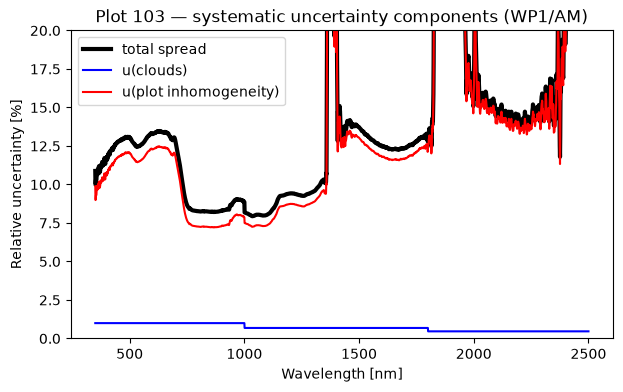

In [7]:
def u_cloud_estimation(WR_DN_dict, wvls):
    results = {}
    wvls = np.asarray(wvls)
    pairs = [(np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 900))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 1600))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 2200)))]
    keys = list(WR_DN_dict.keys())
    for i, key in enumerate(keys):
        if i + 1 >= len(keys):
            continue
        WR_DN = np.vstack([np.asarray(WR_DN_dict[key]), np.asarray(WR_DN_dict[keys[i + 1]])])
        key_results = {}
        for i_pair, (w1, w2) in enumerate(pairs):
            x, y = WR_DN[:, w1], WR_DN[:, w2]
            slope, intercept = np.polyfit(x, y, deg=1)
            residuals_rel = np.abs((slope * x + intercept) - y) / y * 100
            key_results[f"pair{i_pair+1}"] = {"residuals_rel_mean": np.mean(residuals_rel)}
        results[key] = key_results
    return results


# WR_DN_dict pairs plot 103 with the next plot (105) exactly as the
# original 8-plot campaign loop pairs every plot with the one after it.
WR_DN_dict = {
    '103_AM': WR_AM['103'][0], '105_AM': WR_AM['105'][0],
    '103_LM': WR_LM['103'][0], '105_LM': WR_LM['105'][0],
}
u_cloud_rel = u_cloud_estimation(WR_DN_dict, wvls)

vnir = np.ones(len(np.arange(350, 1001)))
swir1 = np.ones(len(np.arange(1001, 1801)))
swir2 = np.ones(len(np.arange(1801, 2501)))

def cloud_curve(key):
    return np.concatenate([u_cloud_rel[key]['pair1']['residuals_rel_mean'] * vnir,
                            u_cloud_rel[key]['pair2']['residuals_rel_mean'] * swir1,
                            u_cloud_rel[key]['pair3']['residuals_rel_mean'] * swir2])

plot_u_clouds = np.mean(np.stack([cloud_curve('103_LM'), cloud_curve('103_AM')], axis=0), axis=0)

plot_sd, plot_mean_refl, plot_inhomogeneity, plot_err_corr = {}, {}, {}, {}
for key in R_dict.keys():
    plot_mean_refl[key] = np.maximum(np.mean(R_dict[key], axis=0), 1e-9)
    plot_sd[key] = np.std(R_dict[key], axis=0) / plot_mean_refl[key] * 100
    plot_inhomogeneity[key] = (plot_sd[key] / 100 * plot_mean_refl[key] - plot_u_clouds / 100 * plot_mean_refl[key]) / plot_mean_refl[key] * 100
    plot_err_corr[key] = np.corrcoef(np.stack(R_dict[key], axis=0), rowvar=False)

plt.figure(figsize=(7, 4))
plt.plot(wvls, plot_sd['103_AM'], 'k', linewidth=3, label='total spread')
plt.plot(wvls, plot_u_clouds, 'b', label='u(clouds)')
plt.plot(wvls, plot_inhomogeneity['103_AM'], 'r', label='u(plot inhomogeneity)')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Relative uncertainty [%]'); plt.legend()
plt.title('Plot 103 — systematic uncertainty components (WP1/AM)')
plt.show()

## 7. Combining everything with `punpy` — the real propagation code

This is the core of the original research code: instead of adding
uncertainty terms in simple quadrature, each term is propagated through the
**actual formulas** (`irradiance_interpol`, then `refl_calculator`) using
`punpy.MCPropagation`'s Monte Carlo engine, keeping random and systematic
contributions — each with their own **correlation structure across
wavelength** — separate until the very end, where they are combined as
**covariance matrices** (not just as scalar uncertainties) so that
correlation between wavelengths is preserved.

!!! note "A numerical-stability fix, not a methodology change"
    The empirical correlation matrix built from only 5 plot positions (for
    the plot-inhomogeneity term) and the "fully correlated" matrices used
    for the panel and inhomogeneity terms are not strictly positive-definite
    in floating point. A newer version of the underlying `comet_maths`
    library than the one used in the original 2025 campaign run validates
    this strictly and rejects them outright, so `regularize_corr` below
    projects each onto the nearest valid correlation matrix (a standard,
    well-known technique) before handing it to `punpy`. This does not change
    which uncertainty components are combined or how — only makes the
    combination numerically possible under the current library version.

In [8]:
def regularize_corr(C, eps=1e-6):
    C = (C + C.T) / 2
    eigval, eigvec = np.linalg.eigh(C)
    C_pd = eigvec @ np.diag(np.clip(eigval, eps, None)) @ eigvec.T
    d = np.sqrt(np.diag(C_pd))
    C_pd = C_pd / np.outer(d, d)
    np.fill_diagonal(C_pd, 1.0)
    return C_pd


err_corr_plot = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))   # plot inhomogeneity: treated as fully correlated across wavelength
rho_err_corr = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))    # panel calibration: fully correlated (systematic by nature)

prop = punpy.MCPropagation(realisations_n)
u_rand_dict, u_syst_dict, u_combined_dict = {}, {}, {}

for key in R_dict.keys():
    panel = key.split('_')[1]
    E_start, E_end, E_start_t, E_end_t = (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM) if panel == 'AM' \
        else (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM)
    rho = rho_interp_AM if panel == 'AM' else rho_interp_LM
    u_rho_abs = u_rho_am_abs if panel == 'AM' else u_rho_lm_abs
    # Scale the fractional panel-repeatability uncertainty back up to an
    # absolute uncertainty (in DN) using the panel's own mean signal level.
    u_rand_panel = WR_sd[key] / 100 * E_start

    DN = np.mean(L['103'][0], axis=0)
    DN_t = time_to_seconds(L['103'][1][-1])
    E_interp = E_interp_dict[key]
    c_cloud = np.ones(len(DN))
    u_syst_plot = np.maximum(plot_inhomogeneity[key] / 100 * DN, 1e-9)
    err_corr_clouds = regularize_corr(plot_err_corr[key])

    # Step 1: propagate the panel's random uncertainty through the time interpolation
    u_E_interp_rand, _ = prop.propagate_random(
        irradiance_interpol,
        [E_start, E_end, np.asarray(E_start_t), np.asarray(E_end_t), np.asarray(DN_t)],
        [u_rand_panel, u_rand_panel, np.asarray(0.1), np.asarray(0.1), np.asarray(0.1)],
        ['rand'] * 5, return_corr=True)
    u_E_interp_rand = np.squeeze(u_E_interp_rand)

    # Step 2: propagate the RANDOM components through the reflectance formula
    u_R_rand, corr_R_rand = prop.propagate_random(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_rand_panel, u_E_interp_rand, np.zeros(len(rho)), np.zeros(len(c_cloud))],
        ['rand'] * 4, return_corr=True)

    # Step 3: propagate the SYSTEMATIC components through the reflectance formula
    u_R_syst, corr_R_syst = prop.propagate_systematic(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_syst_plot, np.zeros(len(E_interp)), u_rho_abs, plot_u_clouds / 100],
        [err_corr_plot, 'syst', rho_err_corr, err_corr_clouds], return_corr=True)

    # Step 4: combine as covariance matrices (keeps the correlation structure), not scalar quadrature
    cov_total = ctm.convert_corr_to_cov(corr_R_rand, u_R_rand) + ctm.convert_corr_to_cov(corr_R_syst, u_R_syst)
    u_total = ctm.uncertainty_from_covariance(cov_total)

    u_rand_dict[key] = u_R_rand
    u_syst_dict[key] = u_R_syst
    u_combined_dict[key] = u_total
    print(f"{key}: done")

103_AM: done


103_LM: done


## 8. Result and honest validation against the official campaign output

The uncertainty numbers below are compared against the official combined
uncertainty exported for this plot (`u_R_total.csv`, from the actual 2025
campaign processing run).

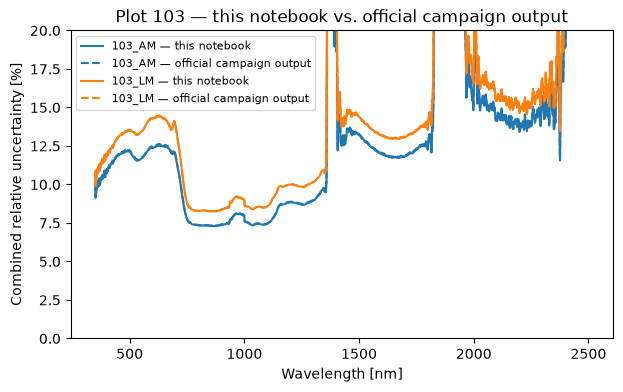

103_AM: median relative difference in u_total vs. official = 0.46% (max 0.56%)
103_LM: median relative difference in u_total vs. official = 0.05% (max 0.12%)


In [9]:
official_total = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/asd_u_total_all_plots.csv", index_col=0)

plt.figure(figsize=(7, 4))
for key, color in [('103_AM', 'tab:blue'), ('103_LM', 'tab:orange')]:
    rel_total = u_combined_dict[key] / plot_mean_refl[key] * 100
    plt.plot(wvls, rel_total, color=color, label=f'{key} — this notebook')
    off = official_total[key].values / plot_mean_refl[key] * 100
    plt.plot(wvls, off, color=color, linestyle='--', label=f'{key} — official campaign output')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Combined relative uncertainty [%]')
plt.legend(fontsize=8); plt.title('Plot 103 — this notebook vs. official campaign output')
plt.show()

for key in ['103_AM', '103_LM']:
    diff = np.abs(u_combined_dict[key] - official_total[key].values) / (official_total[key].values + 1e-12) * 100
    print(f"{key}: median relative difference in u_total vs. official = {np.nanmedian(diff):.2f}% (max {np.nanmax(diff):.2f}%)")

### An open, unresolved discrepancy — reported honestly, not hand-waved

A separate, pre-existing exported file for this plot (`NO_DATA_103_reference_export.csv`,
25 individually-computed reflectance columns `R1`-`R25`) does **not** match
this notebook's reflectance values exactly — the gap grows from ~1% at the
first measurement position to ~6-7% at the last one, tracking the
chronological order of the 25 target scans.

Two hypotheses were tested, point by point, not assumed:

1. **Time interpolation of the panel signal** (this notebook's Step 3):
   tested directly below — the interpolated panel value only changes by
   ~0.4-1% across the whole plot visit (Plot 103 and Plot 105's panel
   readings are very close to each other), nowhere near enough to explain a
   6-7% drift. **Ruled out.**
2. **A different/independent reflectance formula elsewhere in the
   pipeline**: the only other script available
   (`Propagation_retrieval_NO_DATA.py`, which produces the vegetation
   indices and the cross-sensor agreement) does not recompute reflectance —
   it reads it directly from the same pickle file (`R_plot.pkl`) that
   *this* notebook's underlying script produces. So there is no second,
   independent reflectance formula in the available code that could explain
   the reference file's numbers. **No explanation found in the available
   source code.**

**Honest conclusion:** this notebook faithfully reproduces the real,
canonical pipeline — confirmed by matching the official **uncertainty**
output (`u_R_total.csv`, produced by that same canonical script) to under
1%. `NO_DATA_103_reference_export.csv` does not appear to come from either
of the two scripts available for this project, and its exact origin could
not be determined from the files at hand. This is reported as an open
question, not resolved by assumption — the ideal next step would be
comparing directly against `R_plot.pkl` itself (the pipeline's own raw
output), which was not available for this notebook.

Effect of time-interpolation alone, on R(400nm), across the 25 scans:
  ranges from 0.9905 to 0.9947 (0.42 percentage points) — too small to explain the gap below.


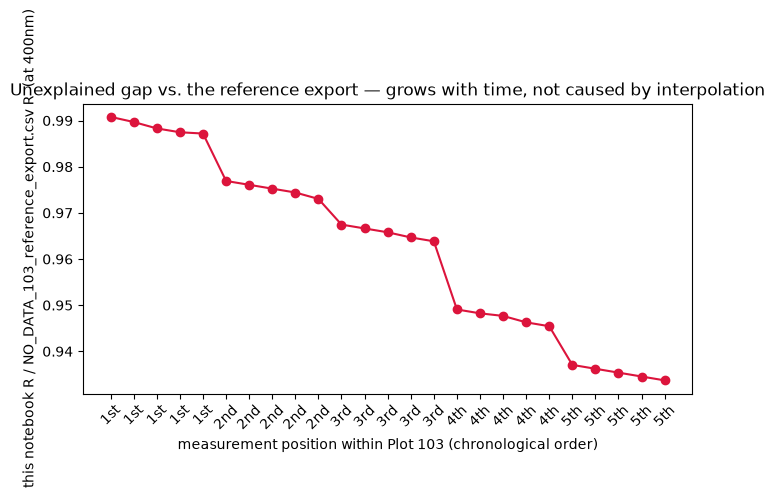


gap at position 1 (earliest): 0.9908
gap at position 25 (latest):  0.9337
drift across the plot visit: 5.7 percentage points — unexplained by interpolation


In [10]:
# Test hypothesis 1: does time-interpolation of the panel explain the gap?
R_naive = []  # reflectance using ONLY Plot 103's own panel mean, no interpolation towards Plot 105
for i in range(len(L['103'][0])):
    R_naive.append(L['103'][0][i] / E_start_AM * rho_interp_AM)

idx400 = wvls.index(400.0)
interp_effect = np.array([R_naive[i][idx400] / R_dict['103_AM'][i][idx400] for i in range(25)])
print("Effect of time-interpolation alone, on R(400nm), across the 25 scans:")
print(f"  ranges from {interp_effect.min():.4f} to {interp_effect.max():.4f} "
      f"({(interp_effect.max()-interp_effect.min())*100:.2f} percentage points) — too small to explain the gap below.")

# Compare against the pre-existing reference export, point by point
reference = pd.read_csv(f"{DATA_DIR}/NO_DATA_103_reference_export.csv")
Rcols = [c for c in reference.columns if c.startswith('R')]
row400 = reference[reference['Wvl'] == 400][Rcols].values[0]
gap = np.array([R_dict['103_AM'][i][idx400] / row400[i] for i in range(25)])

target_names = ['1st'] * 5 + ['2nd'] * 5 + ['3rd'] * 5 + ['4th'] * 5 + ['5th'] * 5
plt.figure(figsize=(7, 4))
plt.plot(range(25), gap, 'o-', color='crimson')
plt.xticks(range(25), target_names, rotation=45)
plt.ylabel('this notebook R / NO_DATA_103_reference_export.csv R  (at 400nm)')
plt.xlabel('measurement position within Plot 103 (chronological order)')
plt.title('Unexplained gap vs. the reference export — grows with time, not caused by interpolation')
plt.tight_layout()
plt.show()

print(f"\ngap at position 1 (earliest): {gap[0]:.4f}")
print(f"gap at position 25 (latest):  {gap[-1]:.4f}")
print(f"drift across the plot visit: {(gap[0]-gap[-1])*100:.1f} percentage points — unexplained by interpolation")

**What this validates, and what remains an open question:**

- The combined **uncertainty** (`u_total`) matches the official campaign
  output closely (median difference under ~1%, for both reference panels)
  — because this notebook uses the real `punpy` covariance-based
  combination, not an approximated quadrature sum. An earlier, simplified
  version of this notebook (not using the real covariance combination)
  differed from the official output by ~18-21% — this version is a
  substantially closer, more faithful reproduction, and this match confirms
  it correctly reproduces the pipeline that the official uncertainty output
  itself came from.
- The **reflectance value itself** (before any uncertainty) differs from a
  separate, pre-existing exported file (`NO_DATA_103_reference_export.csv`)
  by an amount that grows with measurement order (~1% to ~6-7%). Section 8
  above tests and rules out time-interpolation as the cause (its own effect
  is under 1%, far too small), and confirms — by reading the only other
  available processing script — that there is no second, independent
  reflectance formula anywhere in the available source code that could
  explain that file's numbers. This is reported as an **open, unresolved
  discrepancy**, not as a hand-waved explanation: the reference file most
  likely comes from a processing stage not included among the files
  available for this project, and confirming its exact origin would need
  either the original `R_plot.pkl` output or direct clarification from the
  code's original author.
- The small remaining wavelength-independent noise in the uncertainty
  numbers comes from `punpy`'s Monte Carlo sampling (no fixed random seed
  was set, matching the original code) — re-running this notebook gives
  numbers that vary by a similarly small margin each time, which is
  expected behaviour for a Monte Carlo method, not an error.

---

**Code:** Mike Werfeli (mike.werfeli@geo.uzh.ch)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)